# **WEEK 3**

# *TASK 2 Customer Churn Prediction*

# Problem Statement

Customer churn is an important business problem for telecom companies because losing existing customers can reduce revenue and increase customer acquisition costs.

The goal of this project is to build machine learning models that predict whether a customer is likely to churn based on their demographic information, services, contract details, tenure, and billing information.

Two classification algorithms will be developed and compared:

- Logistic Regression
- Decision Tree Classifier

The project will also analyze customer churn patterns, handle categorical variables, examine class imbalance, identify the top three churn-driving features using Decision Tree feature importance, and translate the findings into actionable business insights.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [3]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 3. Dataset Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Data Cleaning

In [11]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [12]:
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Missing TotalCharges: 11


In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [16]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


## 5. Class Imbalance Analysis

The target variable is imbalanced because the number of customers who did not churn is substantially higher than the number of customers who churned.

This means accuracy alone may not provide a complete picture of model performance. Therefore, precision, recall, and F1-score will also be used to evaluate the models.

The train-test split will use stratification to preserve the class distribution in both training and testing datasets.

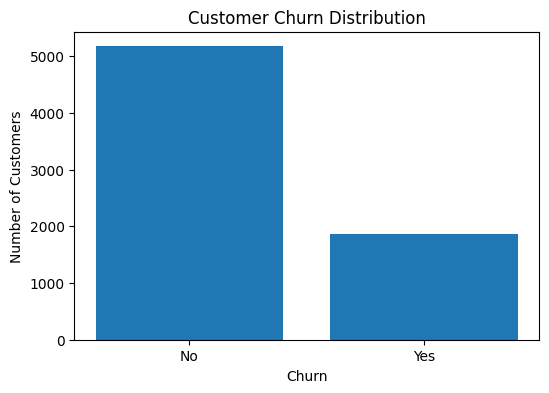

In [17]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

## 6. Exploratory Data Analysis
### Churn by Contract Type

In [18]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


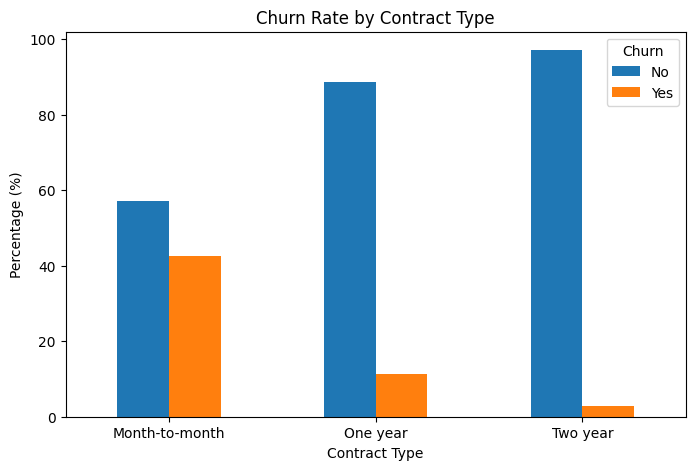

In [19]:
contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

### Churn by Customer Tenure

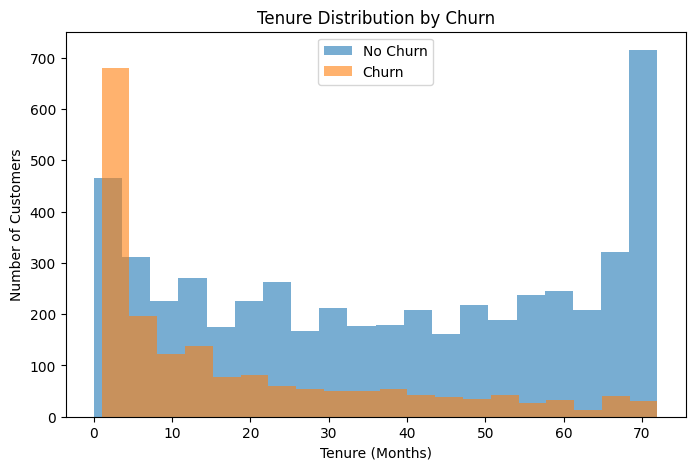

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df['Churn'] == 'No']['tenure'],
    bins=20,
    alpha=0.6,
    label='No Churn'
)

plt.hist(
    df[df['Churn'] == 'Yes']['tenure'],
    bins=20,
    alpha=0.6,
    label='Churn'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()

plt.show()

In [21]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


### Monthly Charges and Churn

In [22]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


<Figure size 700x500 with 0 Axes>

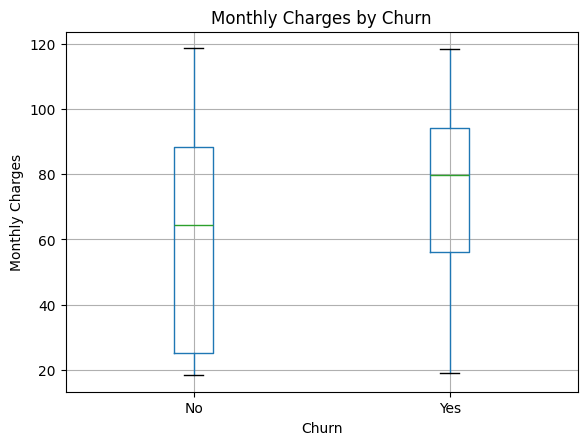

In [24]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column='MonthlyCharges',
    by='Churn'
)

plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

### Churn by Internet Service

In [25]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


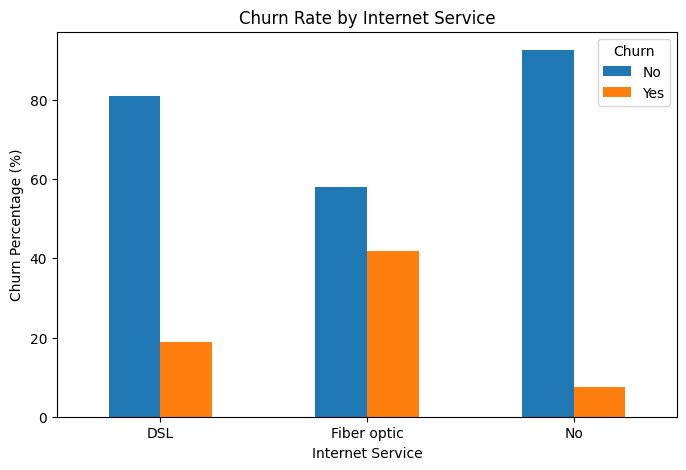

In [26]:
internet_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Percentage (%)')
plt.xticks(rotation=0)

plt.show()

### Churn by Payment Method

In [27]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


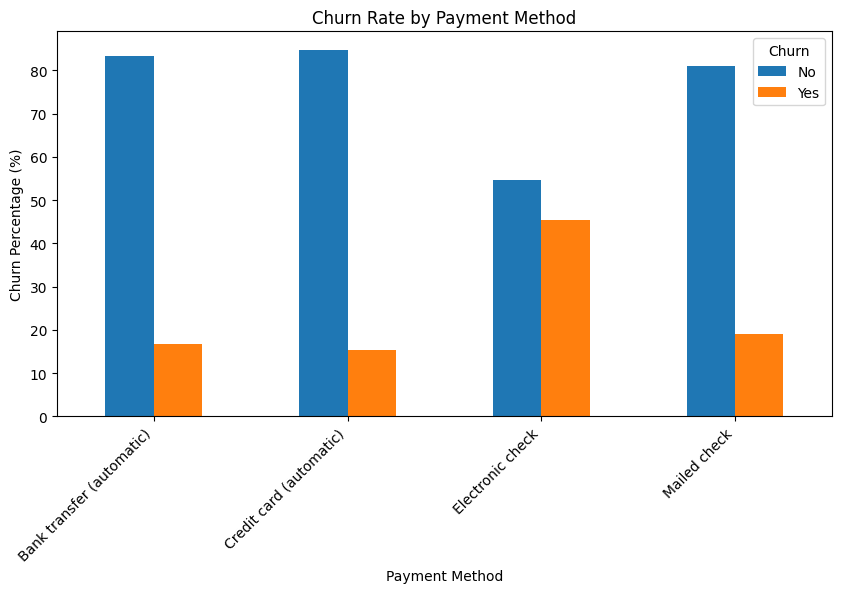

In [28]:
payment_churn.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Percentage (%)')
plt.xticks(rotation=45, ha='right')

plt.show()

## 7. Data Preprocessing

In [29]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [30]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [31]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [32]:
X = X.drop('customerID', axis=1)

In [33]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


## 8. Logistic Regression

In [37]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced'
            )
        )
    ]
)

In [38]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [40]:
y_pred_lr = logistic_model.predict(X_test)

In [41]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1 Score : 0.6136


In [42]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



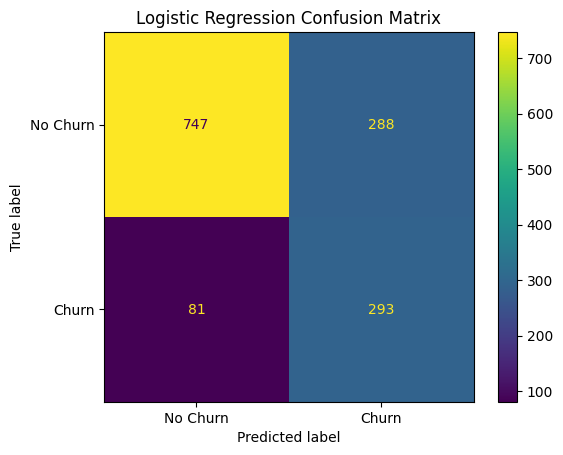

In [43]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

plt.title('Logistic Regression Confusion Matrix')
plt.show()

## 9. Decision Tree Classifier

In [44]:
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42,
                class_weight='balanced'
            )
        )
    ]
)

In [45]:
decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [46]:
y_pred_dt = decision_tree_model.predict(X_test)

In [47]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Results
---------------------
Accuracy : 0.7544
Precision: 0.5260
Recall   : 0.7567
F1 Score : 0.6206


In [48]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



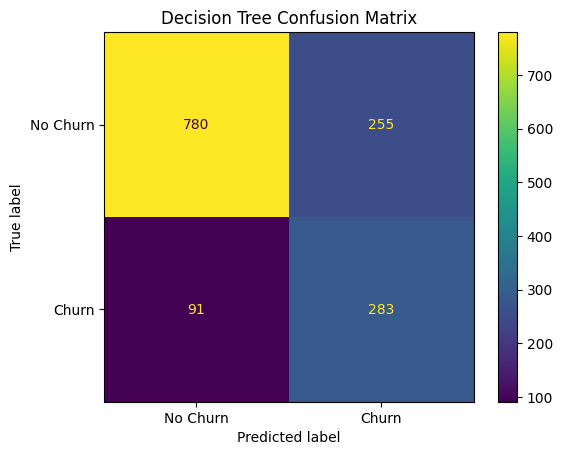

In [49]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

plt.title('Decision Tree Confusion Matrix')
plt.show()

## 10. Model Comparison

In [50]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall
    ],
    'F1 Score': [
        lr_f1,
        dt_f1
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Decision Tree,0.7544,0.5260,0.7567,0.6206


In [51]:
if lr_f1 > dt_f1:
    print("Logistic Regression performed better based on F1 Score.")
elif dt_f1 > lr_f1:
    print("Decision Tree performed better based on F1 Score.")
else:
    print("Both models achieved the same F1 Score.")

Decision Tree performed better based on F1 Score.


In [52]:
tree_model = decision_tree_model.named_steps['classifier']

In [53]:
fitted_preprocessor = decision_tree_model.named_steps['preprocessor']

In [54]:
encoded_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

In [55]:
feature_importances = tree_model.feature_importances_

In [56]:
feature_importance_df = pd.DataFrame({
    'Encoded_Feature': encoded_feature_names,
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(10)

,Encoded_Feature,Importance
36,cat__Contract_Month-to-month,0.609523
1,num__tenure,0.111122
16,cat__InternetService_Fiber optic,0.108187
2,num__MonthlyCharges,0.053637
38,cat__Contract_Two year,0.022793
3,num__TotalCharges,0.021206
27,cat__TechSupport_No,0.019488
43,cat__PaymentMethod_Electronic check,0.013917
18,cat__OnlineSecurity_No,0.012741
11,cat__PhoneService_Yes,0.011654


In [57]:
original_feature_importance = {}

for feature in numerical_features:
    prefix = f'num__{feature}'

    importance = feature_importance_df.loc[
        feature_importance_df['Encoded_Feature'] == prefix,
        'Importance'
    ].sum()

    original_feature_importance[feature] = importance


for feature in categorical_features:
    prefix = f'cat__{feature}_'

    importance = feature_importance_df[
        feature_importance_df['Encoded_Feature'].str.startswith(prefix)
    ]['Importance'].sum()

    original_feature_importance[feature] = importance

In [58]:
original_importance_df = pd.DataFrame(
    original_feature_importance.items(),
    columns=['Feature', 'Importance']
)

In [59]:
original_importance_df = original_importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [60]:
original_importance_df

,Feature,Importance
16,Contract,0.632316
1,tenure,0.111122
9,InternetService,0.108187
2,MonthlyCharges,0.053637
13,TechSupport,0.021238
3,TotalCharges,0.021206
18,PaymentMethod,0.017945
10,OnlineSecurity,0.012741
7,PhoneService,0.011654
6,Dependents,0.005582


In [61]:
top_3_features = original_importance_df.head(3)

top_3_features

,Feature,Importance
16,Contract,0.632316
1,tenure,0.111122
9,InternetService,0.108187


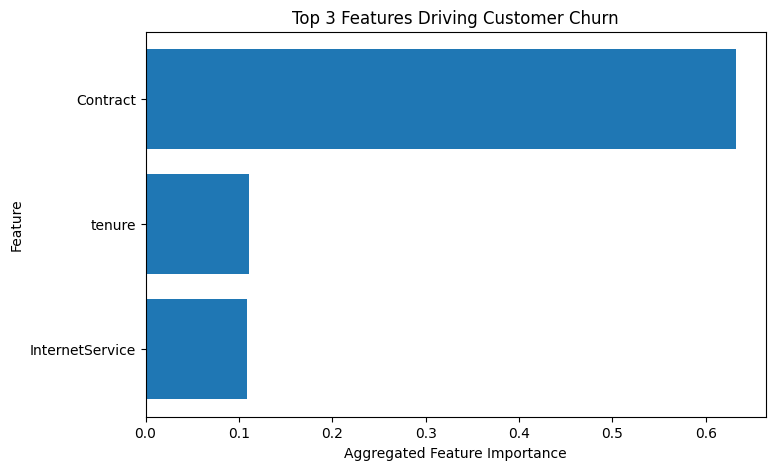

In [62]:
plt.figure(figsize=(8, 5))

plt.barh(
    top_3_features['Feature'],
    top_3_features['Importance']
)

plt.gca().invert_yaxis()

plt.title('Top 3 Features Driving Customer Churn')
plt.xlabel('Aggregated Feature Importance')
plt.ylabel('Feature')

plt.show()

## 11. Conclusion

In this project, I developed machine learning models to predict customer churn using the Telco Customer Churn dataset. Exploratory data analysis was performed to investigate the relationship between customer characteristics and churn. Categorical variables were handled using One-Hot Encoding, while class imbalance was addressed using stratified sampling and balanced class weights during model training. Logistic Regression and Decision Tree Classifier models were trained and evaluated using accuracy, precision, recall, and F1-score. Decision Tree feature importance was further analyzed at the original feature level to identify the top three factors associated with customer churn. These findings demonstrate how machine learning can help businesses identify high-risk customers and develop proactive customer retention strategies.